This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction

In [29]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [30]:
import warnings
warnings.filterwarnings("ignore")

In [31]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "^GSPC"
df_HKstock = yf.download(company, start="2023-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000
...,...,...,...,...,...
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000
2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000


In [32]:
# Save copy to CSV
df_HKstock.to_csv('^GSPC260101.csv')

In [33]:
#
df_source = pd.read_csv("^GSPC260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
1,2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2,2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
3,2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
4,2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000
...,...,...,...,...,...,...
747,2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
748,2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000
749,2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000
750,2025-12-30,6896.240234,6913.250000,6893.470215,6900.439941,3309930000


In [34]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
1,2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2,2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
3,2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
4,2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000
...,...,...,...,...,...,...
747,2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
748,2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000
749,2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000
750,2025-12-30,6896.240234,6913.250000,6893.470215,6900.439941,3309930000


In [35]:
df_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    752 non-null    datetime64[us]
 1   Close   752 non-null    float64       
 2   High    752 non-null    float64       
 3   Low     752 non-null    float64       
 4   Open    752 non-null    float64       
 5   Volume  752 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 35.4 KB


In [36]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 752 entries, 2023-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   752 non-null    float64
 1   High    752 non-null    float64
 2   Low     752 non-null    float64
 3   Open    752 non-null    float64
 4   Volume  752 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.2 KB


In [37]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000
...,...,...,...,...,...
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000
2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000


In [38]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [39]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000
...,...,...,...,...,...
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000
2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000


In [40]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [41]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000,NaN,NaN,NaN
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000,NaN,NaN,0.007539
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000,NaN,NaN,-0.011646
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000,NaN,NaN,0.022841
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000,NaN,NaN,-0.000768
2023-01-10,3919.250000,3919.830078,3877.290039,3888.570068,3851030000,NaN,NaN,0.006978
2023-01-11,3969.610107,3970.070068,3928.540039,3932.350098,4303360000,NaN,NaN,0.012849
2023-01-12,3983.169922,3997.760010,3937.560059,3977.570068,4440260000,NaN,NaN,0.003416
2023-01-13,3999.090088,4003.949951,3947.669922,3960.600098,3939700000,NaN,NaN,0.003997


In [42]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-03-15,3891.929932,3894.260010,3838.239990,3876.739990,6594010000,3984.615515,4003.584209,-0.006981
2023-03-16,3960.280029,3964.459961,3864.110107,3878.929932,5695790000,3975.249512,4006.307012,0.017562
2023-03-17,3916.639893,3958.909912,3901.270020,3958.689941,9354280000,3966.561011,4007.580410,-0.011019
2023-03-20,3951.570068,3956.620117,3916.889893,3917.469971,5347140000,3960.185010,4010.449810,0.008918
2023-03-21,4002.870117,4009.080078,3971.189941,3975.889893,4920240000,3960.461511,4012.605610,0.012982
...,...,...,...,...,...,...,...,...
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000,6842.541968,6784.985977,0.003221
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000,6848.408472,6790.163574,-0.000304
2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000,6851.240991,6795.696982,-0.003492


In [43]:
# Configuration

# For ~ 80:20 Split
test_days = 135

# choose the number of days on which to base our predictions 
nb_days = 60

# Number of days into the future we want to predict
n_steps_out = 30

#
epochsMS=15 
batch_sizeMS = 32
epochs2=30 
batch_size2 = 32

In [44]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [45]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -0.6227048960823581
p-value: 0.8657686789156456
The series is not stationary.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

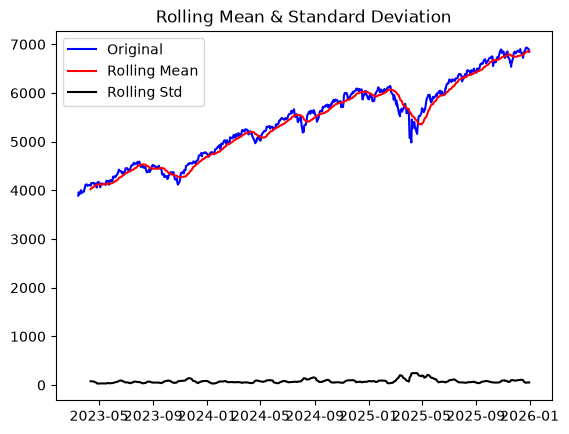

Results of Dickey-Fuller Test:
Test Statistic                  -0.622705
p-value                          0.865769
#Lags Used                       4.000000
Number of Observations Used    698.000000
Critical Value (1%)             -3.439753
Critical Value (5%)             -2.865690
Critical Value (10%)            -2.568980
dtype: float64


In [46]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

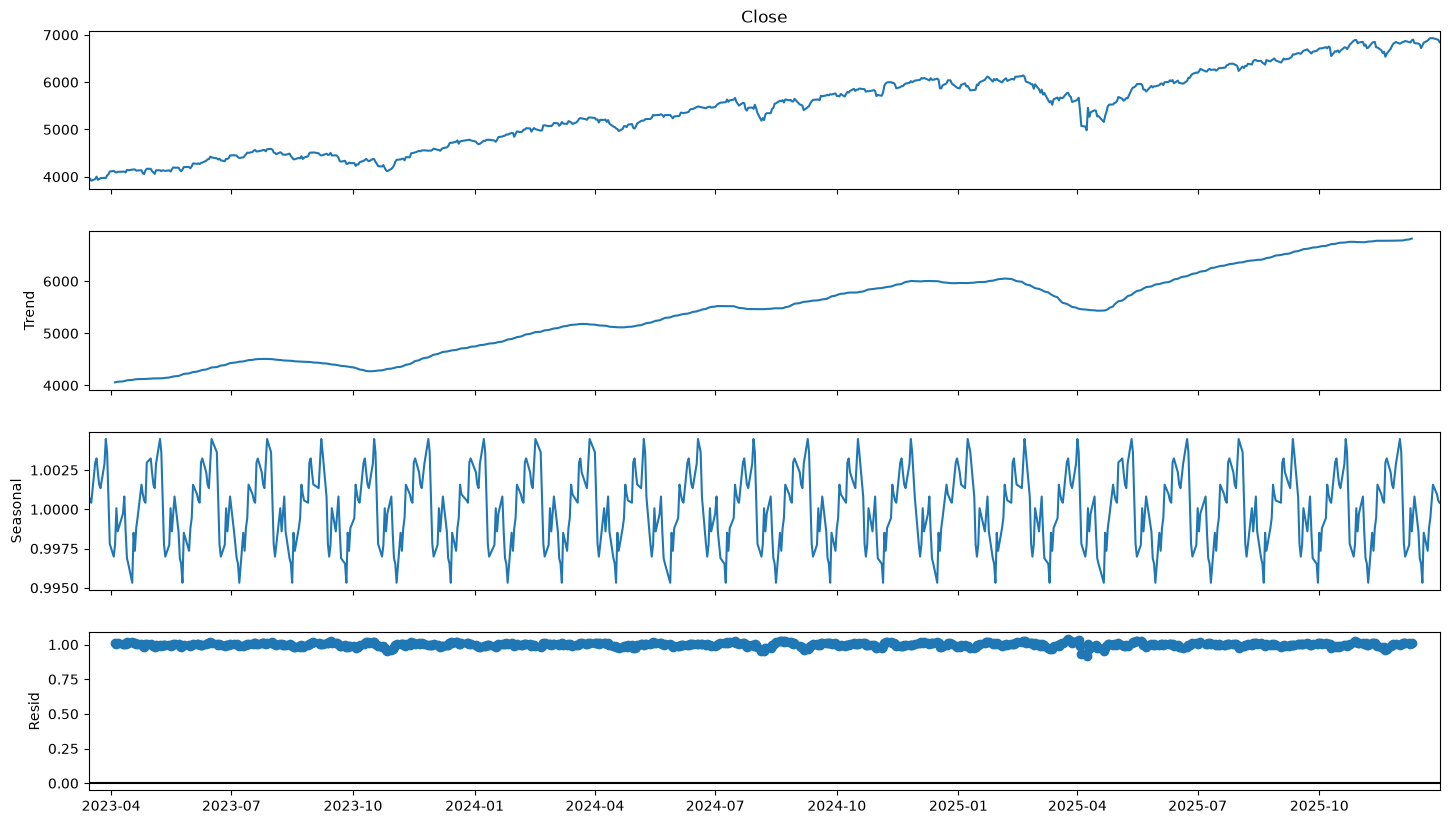

In [47]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

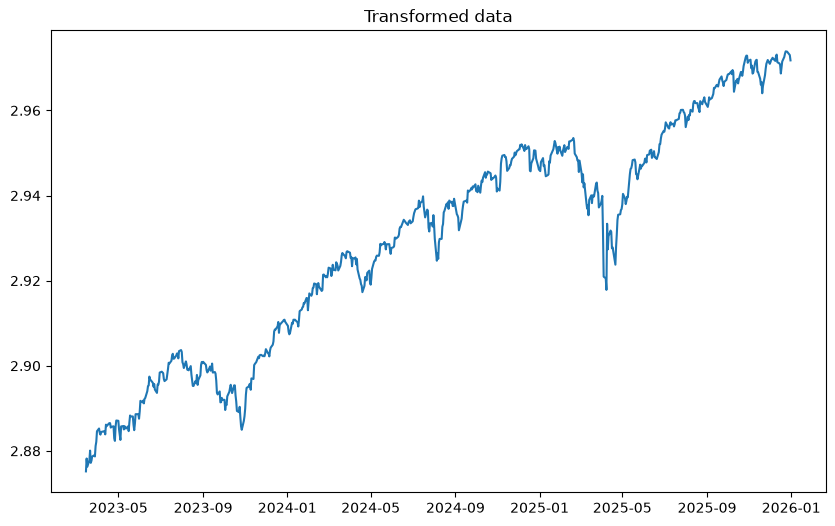

In [48]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

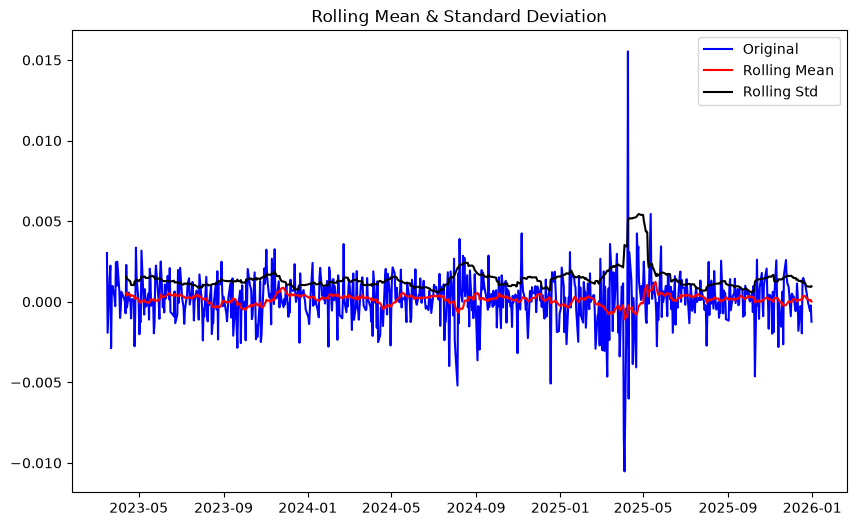

Results of Dickey-Fuller Test:
Test Statistic                -1.513344e+01
p-value                        7.177533e-28
#Lags Used                     3.000000e+00
Number of Observations Used    6.980000e+02
Critical Value (1%)           -3.439753e+00
Critical Value (5%)           -2.865690e+00
Critical Value (10%)          -2.568980e+00
dtype: float64


In [49]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [50]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
#nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

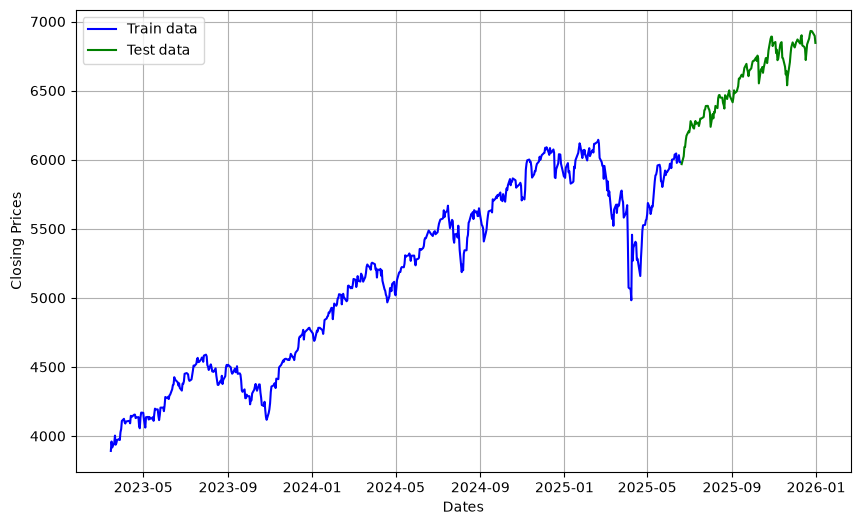

In [51]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [52]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 1.9868e-05 - mean_absolute_error: 0.0036
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.2241e-06 - mean_absolute_error: 0.0020
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 3.7206e-06 - mean_absolute_error: 0.0014
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 3.2030e-06 - mean_absolute_error: 0.0012
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 3.5966e-06 - mean_absolute_error: 0.0013
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 3.1142e-06 - mean_absolute_error: 0.0012
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 3.1221e-06 - mean_absolute_error: 0.0012
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 3.0454e-06 - mean_absolute_error: 0.0012
Epoch 9/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 3.0603e-06 - mean_absolute_error: 0.0012
Epoch 10/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 3.1793e-06 - mean_absolute_error: 0.0012

In [54]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7952e-06 - mean_absolute_error: 0.0010     
Test MSE: 1.7951963400264503e-06
Test MAE: 0.001006350968964398


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


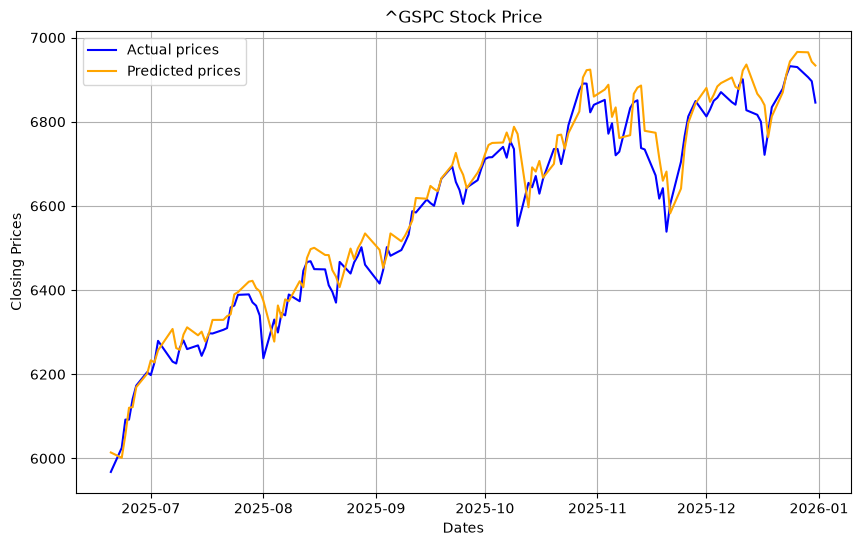

In [55]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

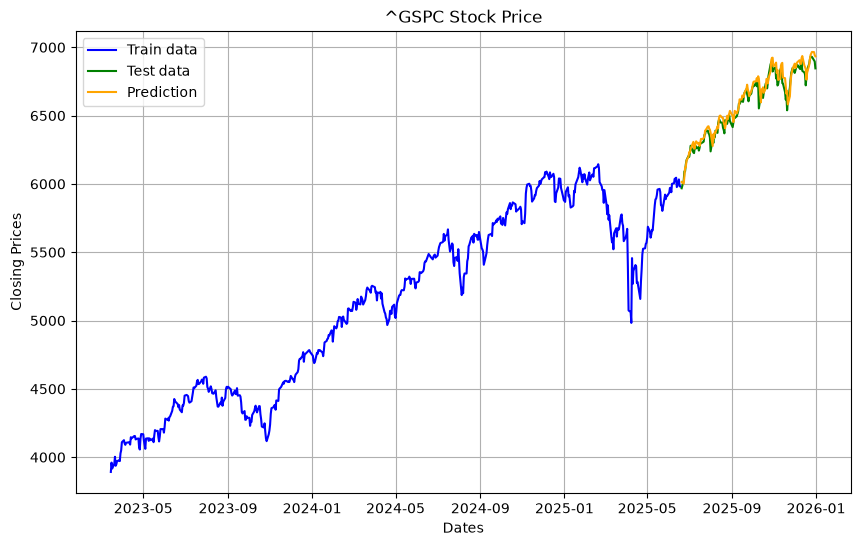

In [56]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [57]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
#n_steps_out = 30

# choose the number of days on which to base our predictions 
#nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [58]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 30)                  │           1,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,930 (46.60 KB)

 Trainable params: 11,930 (46.60 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
#...
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 4.3907e-06 - mean_absolute_error: 0.0015
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 3.4541e-06 - mean_absolute_error: 0.0013
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 3.2499e-06 - mean_absolute_error: 0.0012
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 3.2373e-06 - mean_absolute_error: 0.0012
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 3.2338e-06 - mean_absolute_error: 0.0012
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.2546e-06 - mean_absolute_error: 0.0012
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.2797e-06 - mean_absolute_error: 0.0012
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 3.2956e-06 - mean_absolute_error: 0.0012
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.2581e-06 - mean_absolute_error: 0.0012
Epoch 10/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.2148e-06 - mean_absolute_error: 0.0012

In [60]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5874e-06 - mean_absolute_error: 9.6136e-04 
Test MSE: 1.5874027212703368e-06
Test MAE: 0.000961363548412919


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000017E68C88180> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


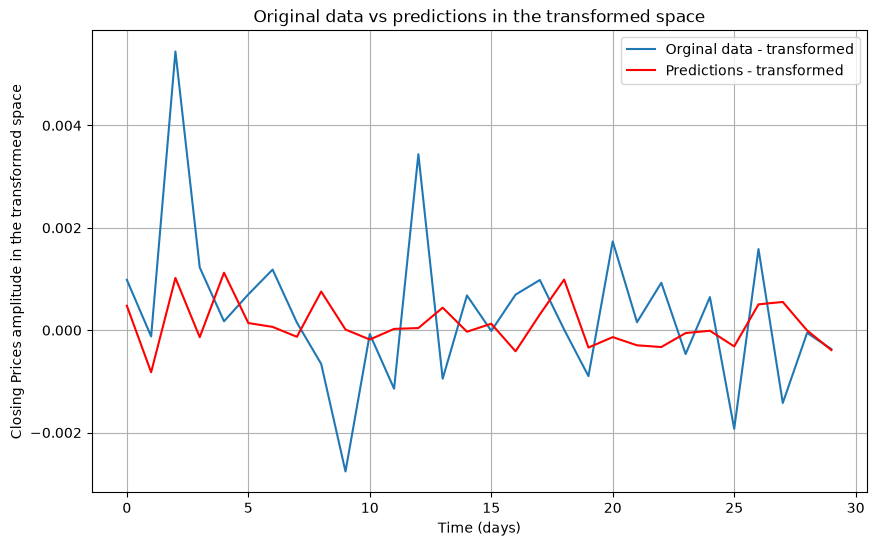

In [61]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [62]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-06-20    2.966475
2025-06-23    2.965653
2025-06-24    2.966675
2025-06-25    2.966538
2025-06-26    2.967661
2025-06-27    2.967801
2025-06-30    2.967865
2025-07-01    2.967736
2025-07-02    2.968491
2025-07-03    2.968504
2025-07-07    2.968322
2025-07-08    2.968347
2025-07-09    2.968389
2025-07-10    2.968830
2025-07-11    2.968800
2025-07-14    2.968926
2025-07-15    2.968514
2025-07-16    2.968822
2025-07-17    2.969812
2025-07-18    2.969473
2025-07-21    2.969338
2025-07-22    2.969043
2025-07-23    2.968714
2025-07-24    2.968658
2025-07-25    2.968647
2025-07-28    2.968330
2025-07-29    2.968835
2025-07-30    2.969387
2025-07-31    2.969382
2025-08-01    2.968993
dtype: float64


In [63]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-06-20    6634.066032
2025-06-23    6601.818899
2025-06-24    6641.930261
2025-06-25    6636.547959
2025-06-26    6680.930507
2025-06-27    6686.484765
2025-06-30    6689.033519
2025-07-01    6683.912602
2025-07-02    6713.940326
2025-07-03    6714.457666
2025-07-07    6707.194701
2025-07-08    6708.205533
2025-07-09    6709.865237
2025-07-10    6727.435216
2025-07-11    6726.253896
2025-07-14    6731.295142
2025-07-15    6714.830227
2025-07-16    6727.147968
2025-07-17    6766.804772
2025-07-18    6753.188517
2025-07-21    6747.765908
2025-07-22    6735.948807
2025-07-23    6722.804931
2025-07-24    6720.573969
2025-07-25    6720.144142
2025-07-28    6707.528694
2025-07-29    6727.666374
2025-07-30    6749.751024
2025-07-31    6749.539297
2025-08-01    6733.970028
dtype: float64


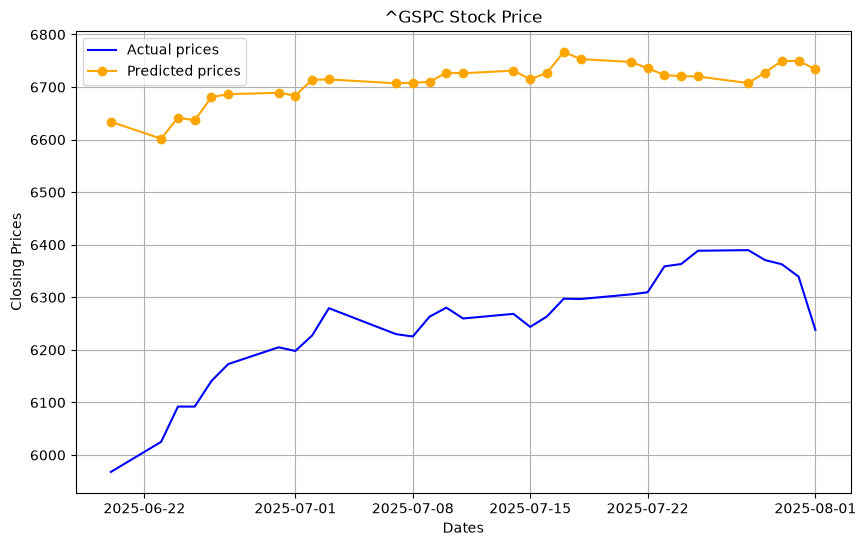

In [64]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [65]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Extract the exact actual prices that align with the prediction period
# Based on your plot, 'pred' starts at 'the_day' and goes forward for 'n_steps_out' steps.
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

# 2. Ensure both are flattened 1D arrays/Series with no missing values
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     70.20
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           4.09e-09
Time:                        23:00:40   Log-Likelihood:                -132.76
No. Observations:                  30   AIC:                             269.5
Df Residuals:                      28   BIC:                             272.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4762.5130    232.348     20.497      0.0

In [67]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# 3. Calculate Directional Accuracy (Crucial for price trends)
# Compares if the predicted direction (up/down) matches the actual direction
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

# 4. Print Evaluation Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      460.4559
Mean Squared Error (MSE):       217430.9128
Root Mean Squared Error (RMSE): 466.2949
Mean Absolute Pct Error (MAPE): 7.39%
Directional Accuracy (DA):      65.52%


In [53]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [54]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [55]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [49]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1538
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0100
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0056
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0033
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0022
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0015
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0014
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0014
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0014
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0013
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0014
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013
Epoc

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [56]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0404
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0075
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0045
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0041
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0033
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0034
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0031
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0026
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0028
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0029
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0030
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0025
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0022
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0022
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0022
Epoc

In [57]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


In [58]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.040284825446442026


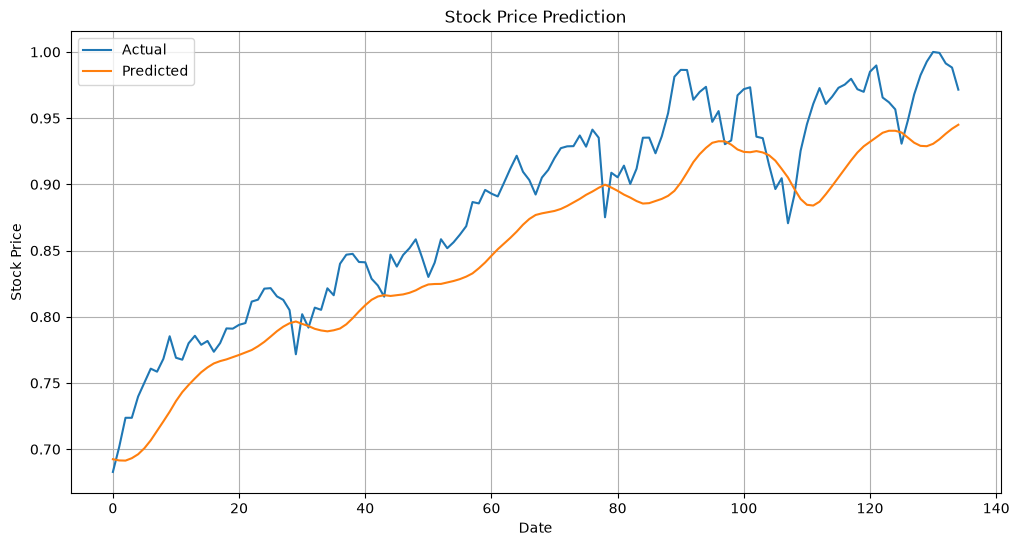

In [59]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.